# Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import classification_report

# Loading the fashion_MINST dataset

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalizing dataset
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
# Flatting images into vectors for input for the MLP moedls
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)
num_classes = 10

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Creating firrst MLP model
- one hidden layer with 128 neurons
- activation function ReLU
- Output layer with softmax activation function
- adam optimization function

In [3]:
model1 = keras.Sequential([ layers.Dense(128, activation='relu', input_shape=(784,)),layers.Dense(num_classes, activation='softmax')])
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Training model
- 40 epochs
- batcch size 128

In [4]:
history1 = model1.fit(X_train, y_train,epochs=40,batch_size=128, validation_data=(X_test, y_test))

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7398 - loss: 0.7521 - val_accuracy: 0.8377 - val_loss: 0.4617
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8552 - loss: 0.4127 - val_accuracy: 0.8539 - val_loss: 0.4192
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8667 - loss: 0.3733 - val_accuracy: 0.8599 - val_loss: 0.3990
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8795 - loss: 0.3447 - val_accuracy: 0.8622 - val_loss: 0.3857
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8839 - loss: 0.3223 - val_accuracy: 0.8635 - val_loss: 0.3737
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8913 - loss: 0.3010 - val_accuracy: 0.8723 - val_loss: 0.3529
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8958 - loss: 0.2885 - val_accuracy: 0.8620 - val_loss: 0.3839
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8969 - loss: 0.2838 - val_accuracy: 0.

# Visualizing results

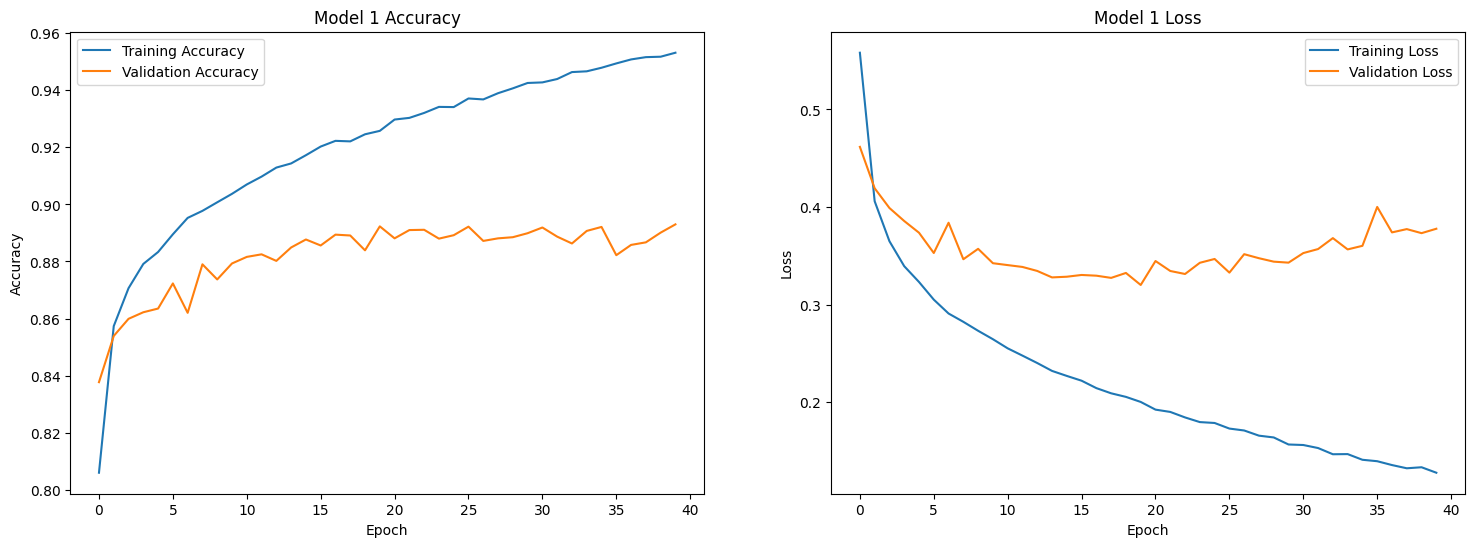

In [5]:
plt.figure(figsize=(18, 6))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Model 1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Wheights for the first MLP

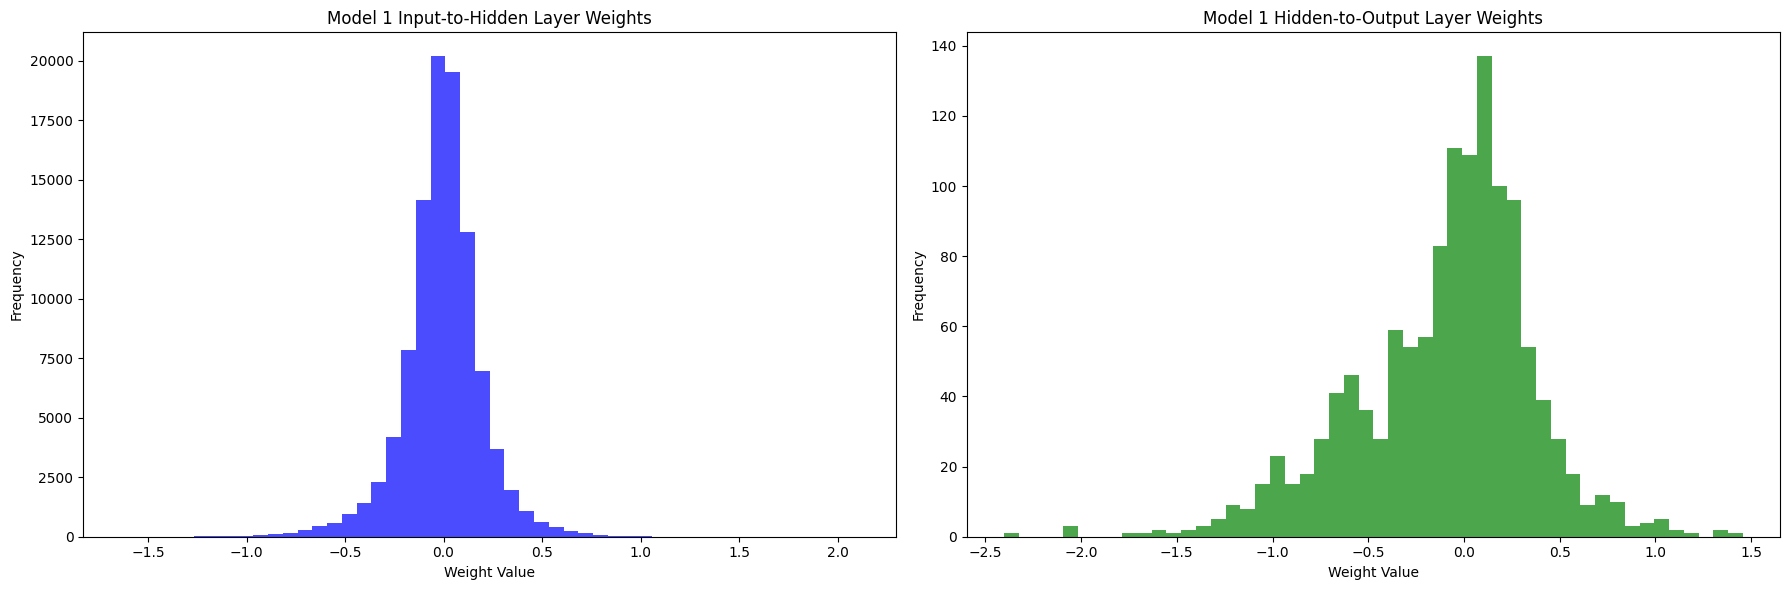

In [6]:
weights1 = model1.get_weights()
plt.figure(figsize=(18, 6))

# input to hidden weights
plt.subplot(1, 2, 1)
plt.hist(weights1[0].flatten(), bins=50, color='blue', alpha=0.7)
plt.title('Model 1 Input-to-Hidden Layer Weights')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')

# hidden to output weights
plt.subplot(1, 2, 2)
plt.hist(weights1[2].flatten(), bins=50, color='green', alpha=0.7)
plt.title('Model 1 Hidden-to-Output Layer Weights')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Creating second MLP model
- one hidden layer with 48 neurons with ReLU activation function
- drop out with rate 0.2
- regularizer L2 with $\lambda = 0.0001$
- output layer with softmax activation function
- adam optimization function

In [7]:
model2 = keras.Sequential([layers.Dense(48, activation='relu', input_shape=(784,), kernel_regularizer=regularizers.l2(0.0001)), layers.Dropout(0.2), layers.Dense(num_classes, activation='softmax')])
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training model
- 40 epochs
- batch size 128

In [8]:
history2 = model2.fit(X_train, y_train, epochs=40, batch_size=128, validation_data=(X_test, y_test))

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6855 - loss: 0.9499 - val_accuracy: 0.8345 - val_loss: 0.4995
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8274 - loss: 0.5145 - val_accuracy: 0.8463 - val_loss: 0.4491
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8430 - loss: 0.4613 - val_accuracy: 0.8529 - val_loss: 0.4314
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8529 - loss: 0.4358 - val_accuracy: 0.8584 - val_loss: 0.4148
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8601 - loss: 0.4123 - val_accuracy: 0.8591 - val_loss: 0.4069
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8635 - loss: 0.4001 - val_accuracy: 0.8634 - val_loss: 0.4051
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8679 - loss: 0.3966 - val_accuracy: 0.8635 - val_loss: 0.3956
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8693 - loss: 0.3809 - val_accuracy: 0.

# Visualize results

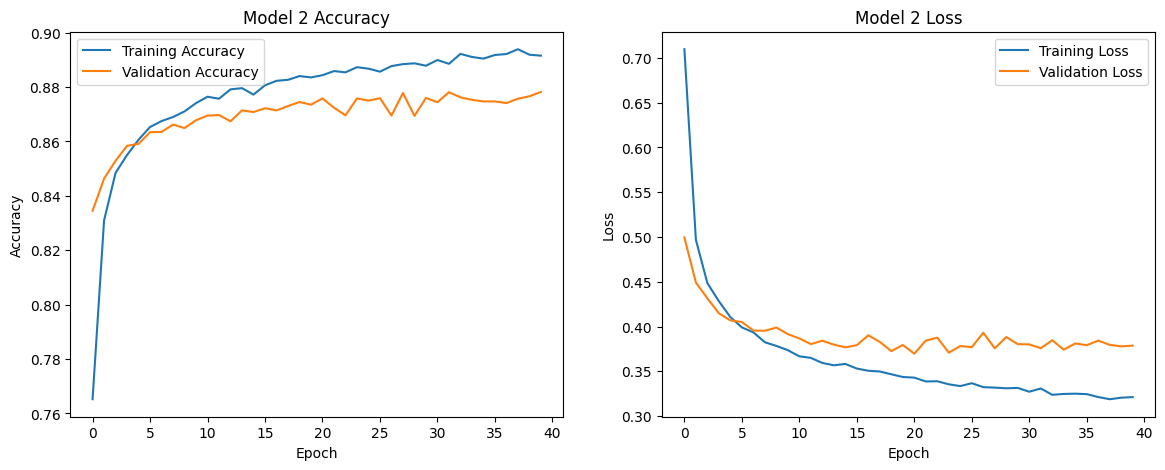

In [9]:
plt.figure(figsize=(14, 5))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model 2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# Weights for the second MLP

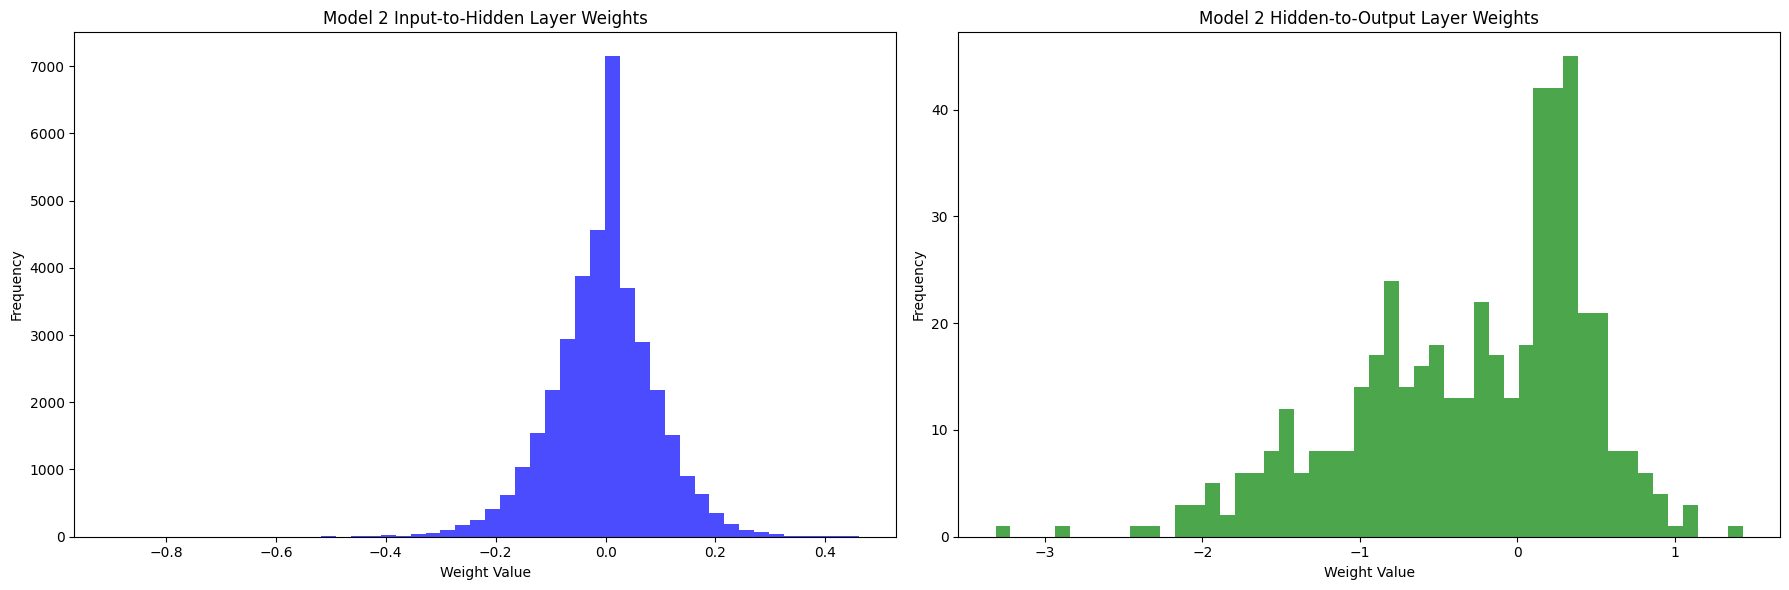

In [10]:
weights2 = model2.get_weights()
plt.figure(figsize=(18, 6))

# input to hidden weights
plt.subplot(1, 2, 1)
plt.hist(weights2[0].flatten(), bins=50, color='blue', alpha=0.7)
plt.title('Model 2 Input-to-Hidden Layer Weights')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')

# hidden to output weights
plt.subplot(1, 2, 2)
plt.hist(weights2[2].flatten(), bins=50, color='green', alpha=0.7)
plt.title('Model 2 Hidden-to-Output Layer Weights')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# Evaluating models

In [11]:
test_loss1, test_acc1 = model1.evaluate(X_test, y_test, verbose=0)
print('Model 1 Test Accuracy:', test_acc1)

test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=0)
print('Model 2 Test Accuracy:', test_acc2)

Model 1 Test Accuracy: 0.8930000066757202
Model 2 Test Accuracy: 0.8781999945640564


# Explaining the difference between histograms



1.   first model
  - input to hidden layer
      - the weihgts are spreaded more which shows a wide distribution and without dropout or reglarization the model has larger weights
  - hidden to output layer
      - again the weights are spreaded with high values this happens because of the abscence of regularization whic allows the weights for growing larger and higher the risk of overfitting
      - this model is close to overfitting
2.   second model
  - input to hidden layer
      - The weights are more distributed around zero
      - Because of L2 regularizer the weights are smaller
      - The presance of forces the model to have more robustness which affects the distribution
  - hidden to output layer
      - weights are again more concenterated but the difference is not significant comparing to the first model.
      - the weights values are smaller this has also happened because of the presance of regularization
      - this model has a lower chance of overfitting as it is indicated in the plots
3. conclusion
Although both validation accuracies are close to 90 percent but looking at the plots it is some how shown that the first model is kind of overfitted to training data





# Using RMSprop instead of adam

In [12]:
model1 = keras.Sequential([ layers.Dense(128, activation='relu', input_shape=(784,)),layers.Dense(num_classes, activation='softmax')])
model1.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model2 = keras.Sequential([layers.Dense(48, activation='relu', input_shape=(784,), kernel_regularizer=regularizers.l2(0.0001)), layers.Dropout(0.2), layers.Dense(num_classes, activation='softmax')])
model2.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [13]:
history1 = model1.fit(X_train, y_train,epochs=40,batch_size=128, validation_data=(X_test, y_test))
history2 = model2.fit(X_train, y_train,epochs=40,batch_size=128, validation_data=(X_test, y_test))

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7352 - loss: 0.7827 - val_accuracy: 0.8397 - val_loss: 0.4549
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8478 - loss: 0.4295 - val_accuracy: 0.8486 - val_loss: 0.4321
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8679 - loss: 0.3673 - val_accuracy: 0.8477 - val_loss: 0.4100
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8781 - loss: 0.3377 - val_accuracy: 0.8735 - val_loss: 0.3624
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8829 - loss: 0.3181 - val_accuracy: 0.8640 - val_loss: 0.3768
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8904 - loss: 0.3029 - val_accuracy: 0.8749 - val_loss: 0.3489
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8940 - loss: 0.2858 - val_accuracy: 0.8697 - val_loss: 0.3630
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8964 - loss: 0.2785 - val_accuracy: 0.

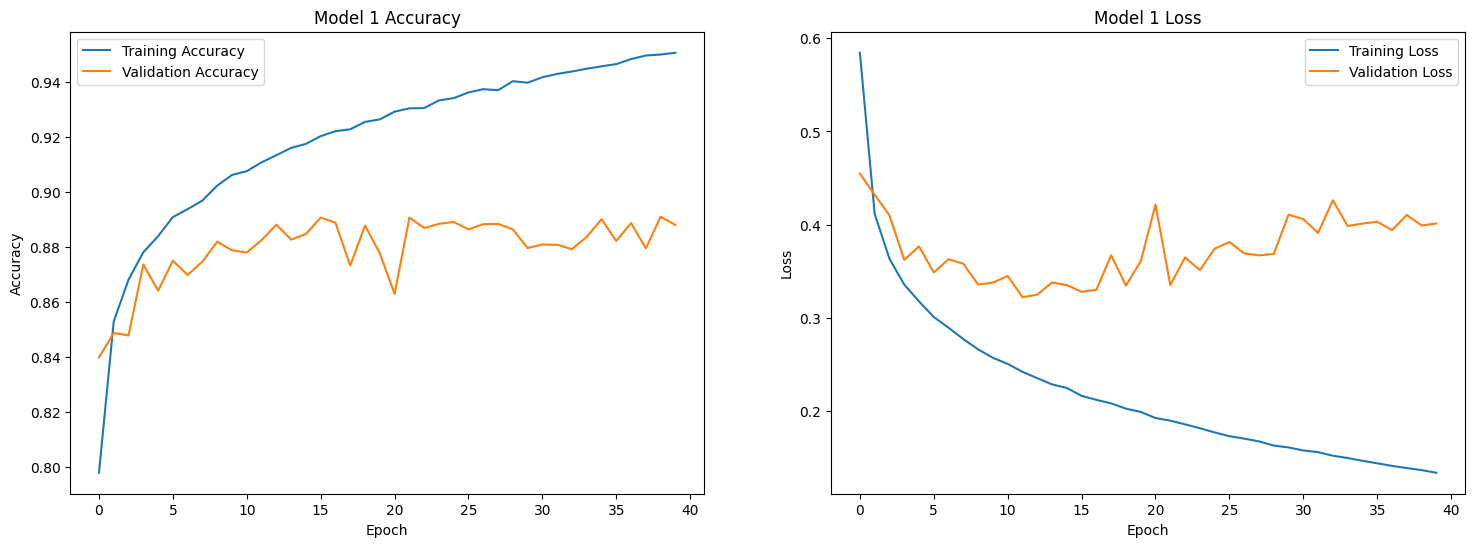

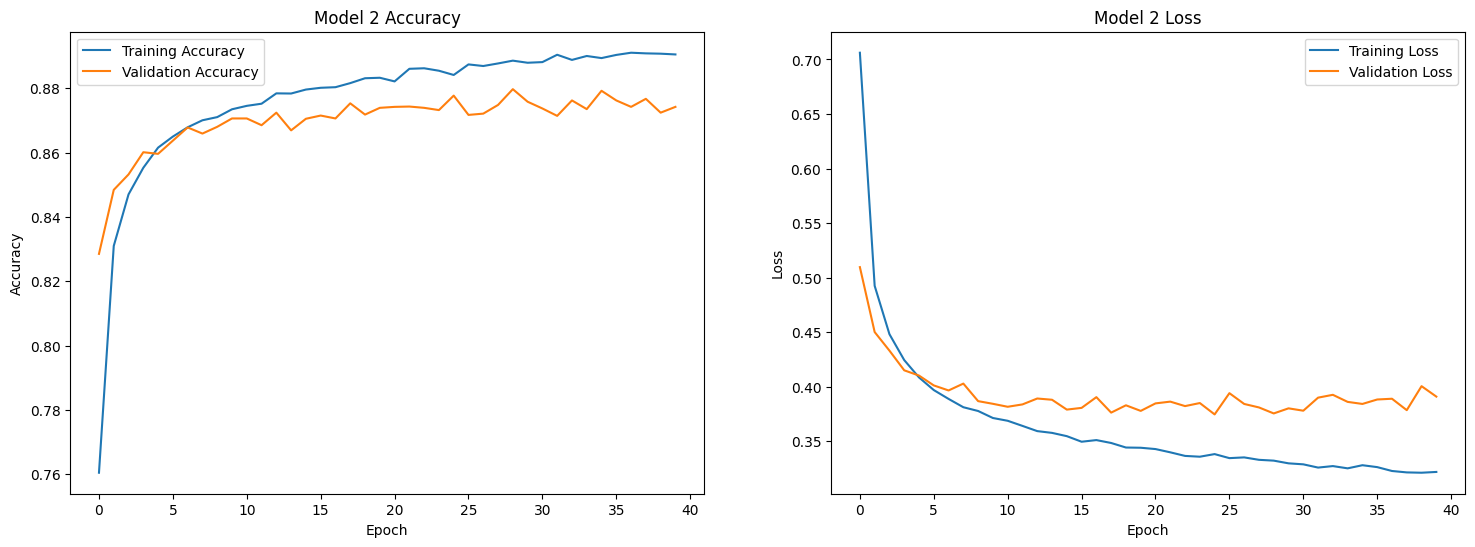

In [14]:
plt.figure(figsize=(18, 6))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Model 1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



plt.figure(figsize=(18, 6))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model 2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [15]:
test_loss1, test_acc1 = model1.evaluate(X_test, y_test, verbose=0)
print('Model 1 Test Accuracy:', test_acc1)

test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=0)
print('Model 2 Test Accuracy:', test_acc2)

Model 1 Test Accuracy: 0.8878999948501587
Model 2 Test Accuracy: 0.8741999864578247


# Using Nadam optimizer


In [18]:
model1 = keras.Sequential([ layers.Dense(128, activation='relu', input_shape=(784,)),layers.Dense(num_classes, activation='softmax')])
model1.compile(optimizer='nadam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model2 = keras.Sequential([layers.Dense(48, activation='relu', input_shape=(784,), kernel_regularizer=regularizers.l2(0.0001)), layers.Dropout(0.2), layers.Dense(num_classes, activation='softmax')])
model2.compile(optimizer='nadam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [19]:
history1 = model1.fit(X_train, y_train,epochs=40,batch_size=128, validation_data=(X_test, y_test))
history2 = model2.fit(X_train, y_train,epochs=40,batch_size=128, validation_data=(X_test, y_test))

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7543 - loss: 0.7460 - val_accuracy: 0.8390 - val_loss: 0.4549
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8592 - loss: 0.4032 - val_accuracy: 0.8575 - val_loss: 0.4099
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8715 - loss: 0.3631 - val_accuracy: 0.8564 - val_loss: 0.4059
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8826 - loss: 0.3323 - val_accuracy: 0.8696 - val_loss: 0.3724
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8857 - loss: 0.3153 - val_accuracy: 0.8712 - val_loss: 0.3614
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8938 - loss: 0.2977 - val_accuracy: 0.8766 - val_loss: 0.3539
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8970 - loss: 0.2856 - val_accuracy: 0.8790 - val_loss: 0.3408
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8991 - loss: 0.2747 - val_accuracy: 0.

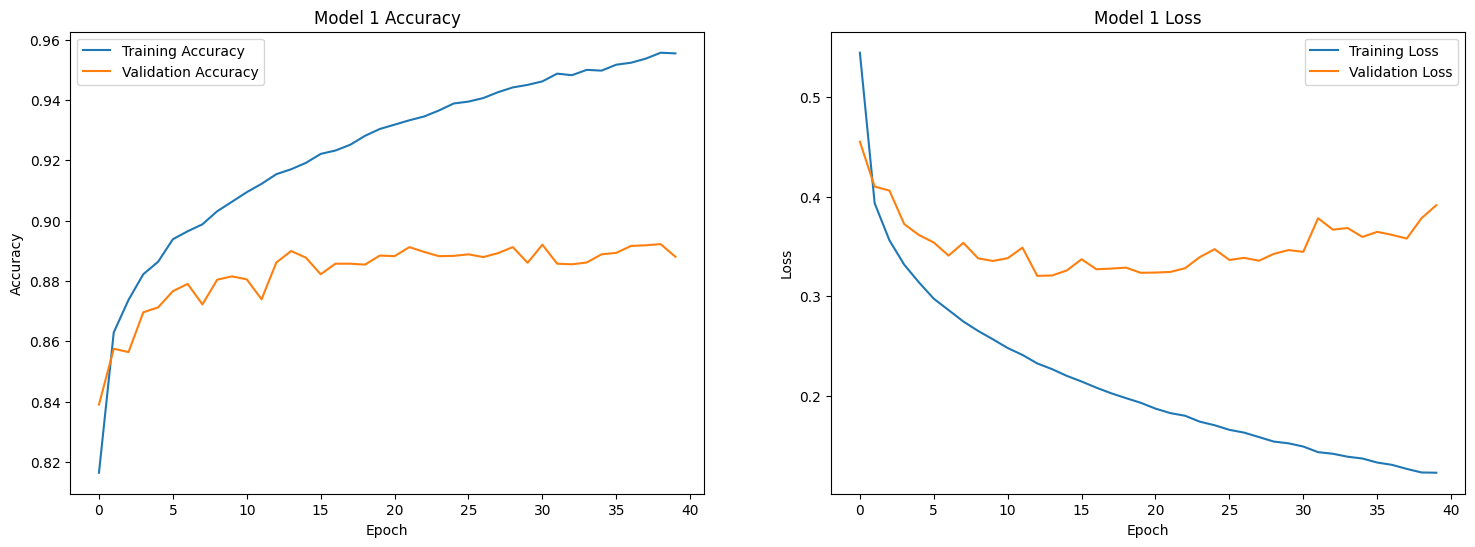

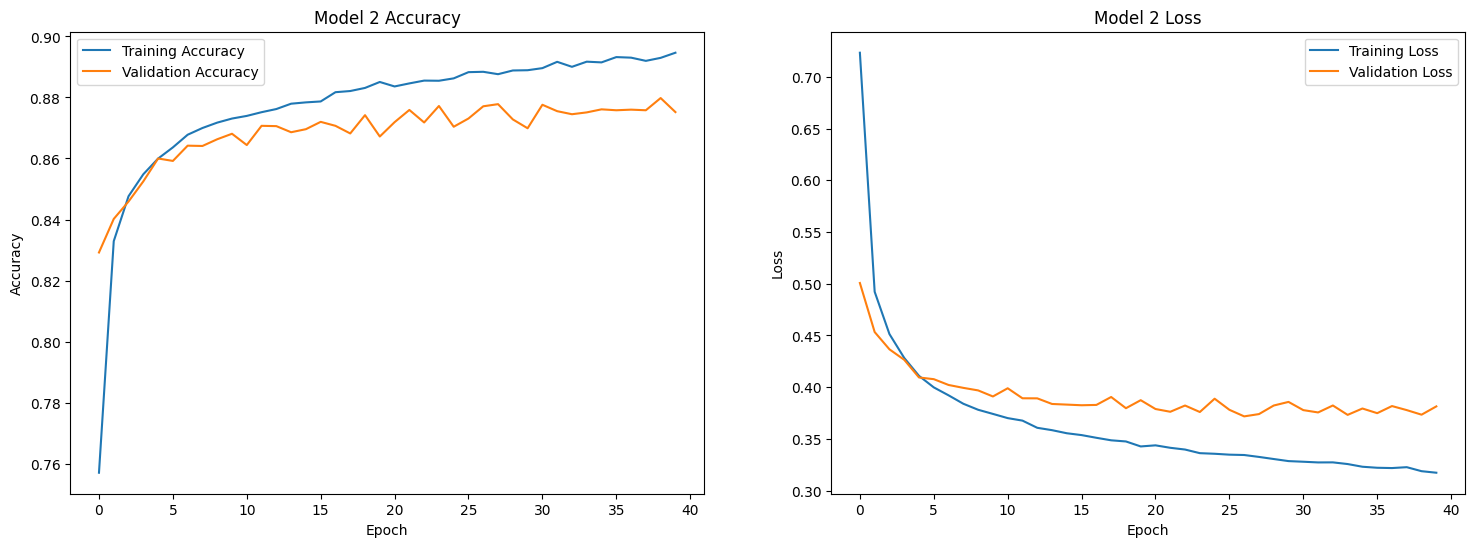

In [20]:
plt.figure(figsize=(18, 6))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Model 1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



plt.figure(figsize=(18, 6))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model 2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [21]:
test_loss1, test_acc1 = model1.evaluate(X_test, y_test, verbose=0)
print('Model 1 Test Accuracy:', test_acc1)

test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=0)
print('Model 2 Test Accuracy:', test_acc2)

Model 1 Test Accuracy: 0.8880000114440918
Model 2 Test Accuracy: 0.8751999735832214


# Comparing the optimization function

looking at results when we evaluate the models with adam amd RMSprop and no optimization function we can see there is little changes in the results so it could be said that for this certain case there is almost no difference weather using adam or RMSprop or even no optimization function at all.

however adding advanced optimiaztion functions generally can improve the performance of the models

finally looking at results we can see that the second model is performing better because the overfitting signs do not exist unlike the first model which there was a significant gap between validation and training loss which is a sign for overfitting